# Antibiotic_resistance_prediction_using_bacterial_genome


In [163]:

import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
from xgboost import XGBClassifier



In [164]:
import pandas as pd
# This import statement is already present in cell 2, so no need to add it again.

# load the three csv files into the notebook
metadata = pd.read_csv("D:\IUBAT\Machine Learning with Python\ML-Tutorial-for-Antibiotic-Resistance-Predictions-for-E.-Coli-main\Datasets\Metadata.csv")
gene_presence_data = pd.read_csv("D:\IUBAT\Machine Learning with Python\ML-Tutorial-for-Antibiotic-Resistance-Predictions-for-E.-Coli-main\Datasets\AccessoryGene.csv")

In [165]:
# Visualize the first 5 rows of our dataframe
metadata.head()

,Lane.accession,MLST,Isolate,Year,CTZ,CTX,AMP,AMX,AMC,TZP,CXM,CET,GEN,TBM,TMP,CIP
0,ERR435312,68.0,11679_6#21,2001.0,S,NaN,NaN,S,S,S,R,NaN,R,NaN,NaN,R
1,ERR434919,652.0,11658_6#85,2005.0,S,S,NaN,S,S,S,S,NaN,S,NaN,NaN,S
2,ERR434399,95.0,11657_6#45,2005.0,S,S,NaN,R,R,R,S,NaN,S,NaN,NaN,S
3,ERR434695,73.0,11658_4#53,2005.0,S,S,NaN,R,S,S,S,NaN,S,NaN,NaN,S
4,ERR434696,73.0,11658_4#54,2005.0,S,S,NaN,R,S,S,S,NaN,S,NaN,NaN,S


In [166]:
# Observe the shape and size of the dataframe
metadata.shape

(1936, 16)

In [167]:
# This prints the mlst sequence types the strains belong to
mlst_list = metadata["MLST"].unique()
mlst_list = mlst_list[np.logical_not(np.isnan(mlst_list))]
print(sorted(mlst_list))
print(len(mlst_list))

[np.float64(-52.0), np.float64(-49.0), np.float64(-48.0), np.float64(-47.0), np.float64(-44.0), np.float64(3.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(14.0), np.float64(20.0), np.float64(23.0), np.float64(28.0), np.float64(34.0), np.float64(38.0), np.float64(43.0), np.float64(44.0), np.float64(46.0), np.float64(48.0), np.float64(57.0), np.float64(58.0), np.float64(59.0), np.float64(62.0), np.float64(68.0), np.float64(69.0), np.float64(70.0), np.float64(73.0), np.float64(74.0), np.float64(75.0), np.float64(79.0), np.float64(80.0), np.float64(83.0), np.float64(86.0), np.float64(88.0), np.float64(90.0), np.float64(91.0), np.float64(93.0), np.float64(95.0), np.float64(100.0), np.float64(101.0), np.float64(104.0), np.float64(106.0), np.float64(115.0), np.float64(117.0), np.float64(121.0), np.float64(124.0), np.float64(126.0), np.float64(127.0), np.float64(129.0), np.float64(130.0), np.float64(131.0), np.float64(135.0), np.float64(136.0), np.float64(141.0), np.floa

<Axes: title={'center': '15 most common Sequence Types in Data'}, ylabel='MLST'>

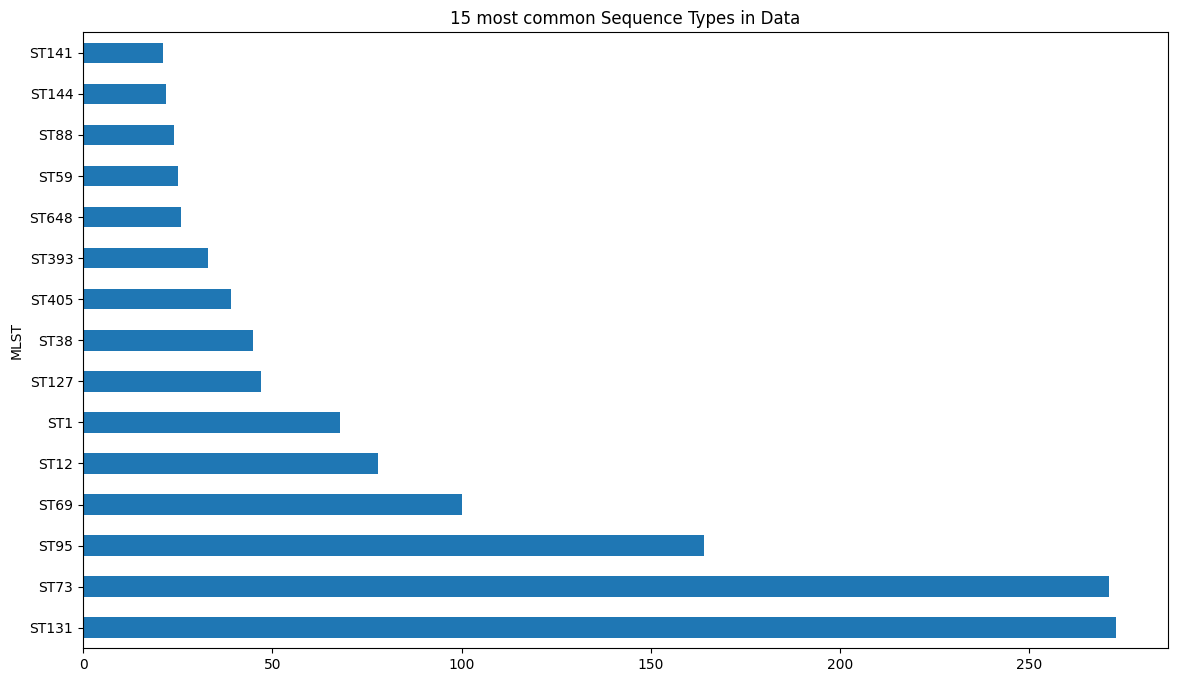

In [168]:
# Check that MLST column is numeric
if is_numeric_dtype(metadata['MLST']):
  # If it is, Add ST infront of numbers to make them into categorical data and strip .0
  metadata['MLST'] = 'ST' + metadata['MLST'].astype(str)
  metadata['MLST'] = metadata['MLST'].map(lambda x: x.rstrip('.0'))
else:
  # If not then make no changes
  metadata['MLST']

# making bar graph to show how many strains we have for each ST group
bplotdata = metadata['MLST'].value_counts().sort_values(ascending = False).head(15)
bplotdata.plot(kind='barh',figsize=(14,8),title="15 most common Sequence Types in Data")

In [169]:
# Checking how many isolates are Resistant vs Susceptible to AMX antibiotic drugs
metadata['AMX'].value_counts()

AMX
R    662
S    432
Name: count, dtype: int64

In [170]:
print(metadata.columns)
print(gene_presence_data.columns)


Index(['Lane.accession', 'MLST', 'Isolate', 'Year', 'CTZ', 'CTX', 'AMP', 'AMX',
       'AMC', 'TZP', 'CXM', 'CET', 'GEN', 'TBM', 'TMP', 'CIP'],
      dtype='object')
Index(['Unnamed: 0', 'yeiU', 'yhhS', 'ybaE', 'eutR', 'ibrB', 'ytfP', 'aslB',
       'narQ', 'tolR',
       ...
       'group_28982', 'pilV_2', 'group_28989', 'group_28998', 'group_29006',
       'group_29010', 'group_29013', 'group_29024', 'group_29035',
       'group_29038'],
      dtype='object', length=16384)


In [171]:
# this code will output the list of named genes and the length of it
named_genes = [col for col in gene_presence_data.drop(columns=["Unnamed: 0"]).columns if 'group' not in col]
print("List of named_genes:")
print(named_genes)
print("Total number of named genes included: ", len(named_genes))

List of named_genes:
['yeiU', 'yhhS', 'ybaE', 'eutR', 'ibrB', 'ytfP', 'aslB', 'narQ', 'tolR', 'galM', 'modB', 'pgl', 'glnQ', 'ydjM', 'osmE', 'rcsF', 'fruB', 'rsuA', 'yfcA', 'ypfN', 'pdxJ', 'plsX', 'ycfF', 'minD', 'marC_2', 'sugE', 'psd', 'nsrR', 'rnfA', 'kbl', 'greB', 'mgsA', 'mukE', 'dtd', 'cpxP', 'fbp', 'luxS', 'fldB', 'epd', 'phoR', 'adk', 'ybbN', 'ilvM', 'ilvE', 'fre', 'glmM', 'gpt', 'aaeX', 'ygcM', 'rplS', 'raiA', 'cvrA', 'hflC_2', 'mgtA', 'speC_2', 'yfeK', 'fsr', 'trmA', 'cmr', 'yceL', 'flgE', 'narG', 'ptsA', 'dmlR_6', 'mutS', 'ybgC', 'moaC', 'artM_1', 'agp', 'sdaA', 'ruvC', 'pgsA', 'yecF', 'yaeT', 'ftsQ', 'ksgA', 'ytjA', 'sanA', 'ccmG', 'nuoK', 'suhB', 'yfiD', 'rpmF', 'fabG_3', 'lolD_2', 'prfA', 'frdC', 'ftsE', 'ycaR', 'cmk', 'fepC', 'ftsB', 'hypA', 'xerD_1', 'rsmE', 'xseB', 'ybaZ', 'ybaB', 'ptsN', 'yeeX', 'yhbP', 'gmr_1', 'sgrR', 'poxB', 'putA', 'clpA', 'ypdC_1', 'pdxK', 'folM', 'ugpB', 'astA', 'yeiA', 'flgK', 'rne', 'chaA', 'mobB', 'ebgA', 'allS_1', 'chaC', 'pdxY', 'yciH', 'rf

In [172]:
# this code will output all the genes without an assigned gene name.
other_genes = [col for col in gene_presence_data.drop(columns=["Unnamed: 0"]).columns if 'group' in col]
print("List of unnamed genes:")
print(other_genes)
print("Total number of unnamed genes included: ", len(other_genes))

List of unnamed genes:
['group_1150', 'group_16546', 'group_2705', 'group_3304', 'group_4923', 'group_4964', 'group_5584', 'group_8156', 'group_8252', 'group_149', 'group_2086', 'group_4319', 'group_5721', 'group_6765', 'group_6877', 'group_698', 'group_8153', 'group_16576', 'group_2284', 'group_6886', 'group_8258', 'group_944', 'group_11031', 'group_1129', 'group_1555', 'group_16561', 'group_2491', 'group_5642', 'group_6779', 'group_776', 'group_10930', 'group_2199', 'group_2731', 'group_4247', 'group_4302', 'group_1533', 'group_1556', 'group_2333', 'group_2498', 'group_2757', 'group_3978', 'group_781', 'group_817', 'group_1153', 'group_1304', 'group_1320', 'group_3797', 'group_6621', 'group_4315', 'group_1139', 'group_4791', 'group_1752', 'group_2311', 'group_3038', 'group_3099', 'group_3784', 'group_4906', 'group_6713', 'group_6771', 'group_1132', 'group_6802', 'group_10939', 'group_1390', 'group_472', 'group_3791', 'group_1518', 'group_3896', 'group_1558', 'group_137', 'group_3451'

In [173]:
# the code below prints all the isolate numbers that have a 1 (presence) for a particular group
print(gene_presence_data[gene_presence_data["group_13605" ]== 1]["Unnamed: 0"])

222      11657_7#39
895      11679_4#73
922      11679_5#10
1066     11679_6#56
1739    24742_1#155
1881    24742_1#295
1883    24742_1#297
1912    24742_1#324
Name: Unnamed: 0, dtype: object


In [174]:
# Observe the shape and size of the dataframe
gene_presence_data.shape


(2033, 16384)

In [175]:
from functools import reduce
# matching the Isolate column name for both datasets
gene_presence_data.rename(columns={'Unnamed: 0': 'Isolate'}, inplace=True)

# List of data sources
df_list = [metadata,gene_presence_data]

# creating a single dataframe with all drugs and features available
Drug_df = reduce(lambda  left,right: pd.merge(left,right,on=['Isolate'], how='inner'), df_list)
Drug_df.head()


,Lane.accession,MLST,Isolate,Year,CTZ,CTX,AMP,AMX,AMC,TZP,...,group_28982,pilV_2,group_28989,group_28998,group_29006,group_29010,group_29013,group_29024,group_29035,group_29038
0,ERR435312,ST68,11679_6#21,2001.0,S,NaN,NaN,S,S,S,...,0,0,0,0,0,0,0,0,0,0
1,ERR434919,ST652,11658_6#85,2005.0,S,S,NaN,S,S,S,...,0,0,0,0,0,0,0,0,0,0
2,ERR434399,ST95,11657_6#45,2005.0,S,S,NaN,R,R,R,...,0,0,0,0,0,0,0,0,0,0
3,ERR434695,ST73,11658_4#53,2005.0,S,S,NaN,R,S,S,...,0,0,0,0,0,0,0,0,0,0
4,ERR434696,ST73,11658_4#54,2005.0,S,S,NaN,R,S,S,...,0,0,0,0,0,0,0,0,0,0


In [176]:
# Deleting Ascension number
Drug_df.drop(columns=["Lane.accession"], axis=1, inplace=True)
Drug_df.head()

,MLST,Isolate,Year,CTZ,CTX,AMP,AMX,AMC,TZP,CXM,...,group_28982,pilV_2,group_28989,group_28998,group_29006,group_29010,group_29013,group_29024,group_29035,group_29038
0,ST68,11679_6#21,2001.0,S,NaN,NaN,S,S,S,R,...,0,0,0,0,0,0,0,0,0,0
1,ST652,11658_6#85,2005.0,S,S,NaN,S,S,S,S,...,0,0,0,0,0,0,0,0,0,0
2,ST95,11657_6#45,2005.0,S,S,NaN,R,R,R,S,...,0,0,0,0,0,0,0,0,0,0
3,ST73,11658_4#53,2005.0,S,S,NaN,R,S,S,S,...,0,0,0,0,0,0,0,0,0,0
4,ST73,11658_4#54,2005.0,S,S,NaN,R,S,S,S,...,0,0,0,0,0,0,0,0,0,0


In [178]:
# Ensure 'MLST' and 'Year' are included as columns in the dataframe
Drug_df.reset_index(inplace=True)

# Check out all the columns included in the final dataframe and the final shape it takes
print(Drug_df.columns)  # contains all labels (drug abbreviation column names)
                        # and all features (year, gene presence absence and population structure)

print("Final shape of combined dataframe", Drug_df.shape)

Index(['MLST', 'Year', 'Isolate', 'CTZ', 'CTX', 'AMP', 'AMX', 'AMC', 'TZP',
       'CXM',
       ...
       'group_28982', 'pilV_2', 'group_28989', 'group_28998', 'group_29006',
       'group_29010', 'group_29013', 'group_29024', 'group_29035',
       'group_29038'],
      dtype='object', length=16398)
Final shape of combined dataframe (1936, 16398)


In [253]:
# Assuming 'Drug_df' is the combined dataframe from the previous cells
# Prepare a dataframe based on the above data from the dataset

# Select relevant columns for analysis
# Here, we assume that 'Drug_df' contains columns for antibiotics and gene presence
antibiotics = ['CIP', 'CTX', 'AMP', 'AMX', 'AMC', 'TZP', 'CXM', 'CET', 'GEN', 'TBM', 'TMP', 'CTZ']
gene_columns = [col for col in Drug_df.columns if col.startswith('group_') or col.startswith('accessory_gene_')]




# Create a new dataframe with selected columns
prepared_df = Drug_df[['Isolate'] + antibiotics + gene_columns]

# Save the prepared dataframe to a CSV file
prepared_df.to_csv('prepared_data.csv', index=False)

# Display the first few rows of the prepared dataframe
prepared_df.head()


,Isolate,CIP,CTX,AMP,AMX,AMC,TZP,CXM,CET,GEN,...,group_28978,group_28982,group_28989,group_28998,group_29006,group_29010,group_29013,group_29024,group_29035,group_29038
0,11679_6#21,R,NaN,NaN,S,S,S,R,NaN,R,...,0,0,0,0,0,0,0,0,0,0
1,11658_6#85,S,S,NaN,S,S,S,S,NaN,S,...,0,0,0,0,0,0,0,0,0,0
2,11657_6#45,S,S,NaN,R,R,R,S,NaN,S,...,0,0,0,0,0,0,0,0,0,0
3,11658_4#53,S,S,NaN,R,S,S,S,NaN,S,...,0,0,0,0,0,0,0,0,0,0
4,11658_4#54,S,S,NaN,R,S,S,S,NaN,S,...,0,0,0,0,0,0,0,0,0,0


In [245]:
import pandas as pd
# Loads csv file as a dataframe
# If the file is "not found" go back to Notebook 1 to make sure you create the file in your Drive.
filepath ='D:\IUBAT\Machine Learning with Python\Supervised-Learning-for-Antibiotic-Resistance-Prediction\prepared_data.csv'

# reads csv file as a dataframe
All_Drugs_df = pd.read_csv(filepath, na_values="NaN")
All_Drugs_df.head

C:\Users\Shuchuna\AppData\Local\Temp\ipykernel_16756\2970541067.py:7: DtypeWarning: Columns (3,4,5,6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  All_Drugs_df = pd.read_csv(filepath, na_values="NaN")


<bound method NDFrame.head of          Isolate CIP  CTX  AMP  AMX  AMC  TZP CXM  CET GEN  ... group_28978  \
0     11679_6#21   R  NaN  NaN    S    S    S   R  NaN   R  ...           0   
1     11658_6#85   S    S  NaN    S    S    S   S  NaN   S  ...           0   
2     11657_6#45   S    S  NaN    R    R    R   S  NaN   S  ...           0   
3     11658_4#53   S    S  NaN    R    S    S   S  NaN   S  ...           0   
4     11658_4#54   S    S  NaN    R    S    S   S  NaN   S  ...           0   
...          ...  ..  ...  ...  ...  ...  ...  ..  ...  ..  ...         ...   
1931  24742_1#96   S    S    S  NaN  NaN  NaN   S    S   S  ...           0   
1932  24742_1#97   S    S    S  NaN  NaN  NaN   S    S   S  ...           0   
1933  24742_1#98   S    S    R  NaN  NaN  NaN   S    S   S  ...           0   
1934  24742_1#99   S    S    R  NaN  NaN  NaN   S    S   S  ...           0   
1935   24742_1#9   S    S    R  NaN  NaN  NaN   S    S   S  ...           0   

     group_28982 grou

In [248]:
#here we make a list of the antibiotics in our combined dataframe
drug_list = All_Drugs_df.iloc[:,3:15].columns
drug_list

Index(['AMP', 'AMX', 'AMC', 'TZP', 'CXM', 'CET', 'GEN', 'TBM', 'TMP', 'CTZ',
       'group_1150', 'group_16546'],
      dtype='object')

In [366]:
def Split_train_test_antibiotic(drug):
    # Ensure that 'MLST' and 'Isolate' are kept
    selected_cols = ["MLST", "Isolate", drug]
    feature_cols = All_Drugs_df.columns[15:]  # assumes features start from column index 15
    df_list = [All_Drugs_df[selected_cols], All_Drugs_df[feature_cols]]
    Drug_df = pd.concat(df_list, axis=1)

    # Drop rows with missing labels
    Drug_df = Drug_df.dropna(subset=[drug])

    y = Drug_df[drug].values.ravel()  # Convert y to a 1d array
    X = Drug_df.drop(columns=[drug])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }


In [367]:
# Accessing a particular chunk of data
print("Class Counts for Training Dataset:")
CTZ_Train_test_dic["y_train"].value_counts()

Class Counts for Training Dataset:


CTZ
S    1336
R     212
Name: count, dtype: int64

In [368]:
# Accessing a particular chunk of data
print("Class Counts for Testing Dataset:")
CTZ_Train_test_dic["y_test"].value_counts()

Class Counts for Testing Dataset:


CTZ
S    334
R     53
Name: count, dtype: int64

In [371]:
def combo_feat(features_df, drug, combo):
    year_filter = [col for col in features_df if col.startswith("Year")]
    year_feat = features_df[year_filter]

    gene_presc_filter = [col for col in features_df.columns if col not in year_filter and col not in ["Isolate", drug]]
    gene_presc_feat = features_df[gene_presc_filter]

    mlst_feat = features_df[["MLST"]]  # Now this will work

    if combo == 'Y':
        return pd.concat([mlst_feat, year_feat], axis=1)

    if combo == 'G':
        return pd.concat([mlst_feat, gene_presc_feat], axis=1)

    if combo == 'GY':
        return pd.concat([mlst_feat, year_feat, gene_presc_feat], axis=1)


In [372]:
print(CTZ_Train_test_dic['X_train'].columns.tolist())


['MLST', 'Isolate', 'group_2705', 'group_3304', 'group_4923', 'group_4964', 'group_5584', 'group_8156', 'group_8252', 'group_149', 'group_2086', 'group_4319', 'group_5721', 'group_6765', 'group_6877', 'group_698', 'group_8153', 'group_16576', 'group_2284', 'group_6886', 'group_8258', 'group_944', 'group_11031', 'group_1129', 'group_1555', 'group_16561', 'group_2491', 'group_5642', 'group_6779', 'group_776', 'group_10930', 'group_2199', 'group_2731', 'group_4247', 'group_4302', 'group_1533', 'group_1556', 'group_2333', 'group_2498', 'group_2757', 'group_3978', 'group_781', 'group_817', 'group_1153', 'group_1304', 'group_1320', 'group_3797', 'group_6621', 'group_4315', 'group_1139', 'group_4791', 'group_1752', 'group_2311', 'group_3038', 'group_3099', 'group_3784', 'group_4906', 'group_6713', 'group_6771', 'group_1132', 'group_6802', 'group_10939', 'group_1390', 'group_472', 'group_3791', 'group_1518', 'group_3896', 'group_1558', 'group_137', 'group_3451', 'group_4351', 'group_16512', 'g

In [373]:
print("All columns in All_Drugs_df:")
for col in All_Drugs_df.columns:
    print(f"'{col}'")


All columns in All_Drugs_df:
'Isolate'
'CIP'
'CTX'
'AMP'
'AMX'
'AMC'
'TZP'
'CXM'
'CET'
'GEN'
'TBM'
'TMP'
'CTZ'
'group_1150'
'group_16546'
'group_2705'
'group_3304'
'group_4923'
'group_4964'
'group_5584'
'group_8156'
'group_8252'
'group_149'
'group_2086'
'group_4319'
'group_5721'
'group_6765'
'group_6877'
'group_698'
'group_8153'
'group_16576'
'group_2284'
'group_6886'
'group_8258'
'group_944'
'group_11031'
'group_1129'
'group_1555'
'group_16561'
'group_2491'
'group_5642'
'group_6779'
'group_776'
'group_10930'
'group_2199'
'group_2731'
'group_4247'
'group_4302'
'group_1533'
'group_1556'
'group_2333'
'group_2498'
'group_2757'
'group_3978'
'group_781'
'group_817'
'group_1153'
'group_1304'
'group_1320'
'group_3797'
'group_6621'
'group_4315'
'group_1139'
'group_4791'
'group_1752'
'group_2311'
'group_3038'
'group_3099'
'group_3784'
'group_4906'
'group_6713'
'group_6771'
'group_1132'
'group_6802'
'group_10939'
'group_1390'
'group_472'
'group_3791'
'group_1518'
'group_3896'
'group_1558'
'group

In [374]:
# A separate dataframe with Isolate and MLST info
mlst_df = pd.read_csv("mlst_data.csv")  # or however you're loading it
# mlst_df should have columns: ['Isolate', 'MLST']


In [375]:
All_Drugs_df = pd.merge(All_Drugs_df, mlst_df, on='Isolate', how='left')


MergeError: Passing 'suffixes' which cause duplicate columns {'MLST_x'} is not allowed.

In [376]:
print(All_Drugs_df[['Isolate', 'MLST']].head())


      Isolate   MLST
0  11679_6#21   ST68
1  11658_6#85  ST652
2  11657_6#45   ST95
3  11658_4#53   ST73
4  11658_4#54   ST73


In [377]:
print(All_Drugs_df.columns)


Index(['Isolate', 'CIP', 'CTX', 'AMP', 'AMX', 'AMC', 'TZP', 'CXM', 'CET',
       'GEN',
       ...
       'group_28998', 'group_29006', 'group_29010', 'group_29013',
       'group_29024', 'group_29035', 'group_29038', 'MLST_x', 'MLST_y',
       'MLST'],
      dtype='object', length=12626)


In [378]:
CTZ_Train_test_dic = Split_train_test_antibiotic("CTZ")
CTZ_GY_train_feat = combo_feat(CTZ_Train_test_dic['X_train'], "CTZ", "GY")
print(CTZ_GY_train_feat.columns)


Index(['MLST', 'MLST', 'MLST', 'MLST', 'group_2705', 'group_3304',
       'group_4923', 'group_4964', 'group_5584', 'group_8156',
       ...
       'group_29006', 'group_29010', 'group_29013', 'group_29024',
       'group_29035', 'group_29038', 'MLST_x', 'MLST_y', 'MLST', 'MLST'],
      dtype='object', length=12616)


In [379]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

def run_LG(feat_train_df, lab_train, drug, combo):
    print(drug + " Training combo: " + combo)

    feat = feat_train_df.copy()

    # Encode MLST if it exists and is not numeric
    if 'MLST' in feat.columns:
        mlst_col = feat[['MLST']]
    else:
        mlst_col = None

    if mlst_col is not None and mlst_col.shape[1] == 1:
        mlst_series = mlst_col.iloc[:, 0]
        if not pd.api.types.is_numeric_dtype(mlst_series):
            le = LabelEncoder()
            feat['MLST'] = le.fit_transform(mlst_series.astype(str))

    # Drop non-numeric columns just in case
    feat = feat.select_dtypes(include=[np.number])

    LG = LogisticRegression(random_state=42, max_iter=500, class_weight='balanced')
    return LG.fit(feat, lab_train)


In [380]:
# implementing run_LG() for specific drug feature combination dataframe
LG_CTZ_GY_model = run_LG(CTZ_GY_train_feat, CTZ_Train_test_dic['y_train'], "CTZ", "GY")

LG_CTZ_GY_model

CTZ Training combo: GY


LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [381]:
# looking at what classes the model is able to predict
LG_CTZ_GY_model.classes_

array(['R', 'S'], dtype=object)

In [382]:
# printing the beta_0 or intercept value of our model
print("Intercept:",LG_CTZ_GY_model.intercept_[0])

# printing all the beta_j's or coefficients of our logistic regression model
print("All beta_j values:", LG_CTZ_GY_model.coef_[0])

# printing the number of all the beta_j values
print("Number of beta_j values: ", len(LG_CTZ_GY_model.coef_[0]))

Intercept: 0.0010650774036085112
All beta_j values: [-0.00319526 -0.0003822  -0.00106459 ...  0.00054326  0.00598183
  0.00053342]
Number of beta_j values:  12608


In [383]:
# creating a function using the model created and trained and the feature combinations from testing data
def predict(LG_combo_Model, features_test):
  feat = features_test.drop(columns=['MLST'])
  labels_pred = LG_combo_Model.predict(feat)
  if is_numeric_dtype(labels_pred):
    # tranforming labels from numbers to letters
    lab_pred_t = labels_pred.astype('O')
    lab_pred_t[lab_pred_t==0] = 'R'
    lab_pred_t[lab_pred_t==1] = 'S'
    return lab_pred_t
  else:
    return labels_pred

In [384]:
# Implementing combo_feat() function created for testing data
CTZ_GY_test_df = combo_feat(CTZ_Train_test_dic['X_test'],"CTZ","GY")

In [385]:
LG_CTZ_GY_model = run_LG(CTZ_GY_train_feat, CTZ_Train_test_dic['y_train'], "CTZ", "GY")


CTZ Training combo: GY


In [390]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

def preprocess_test_data(feat_test_df, label_encoder=None):
    """
    Preprocess the test data to apply the same transformations as the training data.
    Specifically, handle the 'MLST' column and return transformed features.
    """
    feat = feat_test_df.copy()
    
    # Encode 'MLST' column if it's categorical and not numeric
    if 'MLST' in feat.columns:
        mlst_series = feat['MLST']
        if not pd.api.types.is_numeric_dtype(mlst_series):  # Check if MLST is not numeric
            if label_encoder is None:  # If no label encoder passed, fit a new one
                label_encoder = LabelEncoder()
                feat['MLST'] = label_encoder.fit_transform(mlst_series.astype(str))  # Apply encoding
            else:  # If label_encoder passed, use it to transform
                feat['MLST'] = label_encoder.transform(mlst_series.astype(str))  # Apply encoding
        else:
            print("MLST column is already numeric, skipping encoding.")
    
    # Drop non-numeric columns, ensure features are numeric
    feat = feat.select_dtypes(include=[np.number])
    
    return feat, label_encoder


In [391]:
def predict(model, feat_test_df, label_encoder=None):
    # Preprocess the test data (apply the same transformations as the training data)
    feat_test_df_processed, label_encoder = preprocess_test_data(feat_test_df, label_encoder)
    
    # Make predictions using the trained model
    return model.predict(feat_test_df_processed)


In [393]:
y_train = CTZ_Train_test_dic['y_train']  # Correct way to get y_train


In [394]:
y_train = np.ravel(y_train)


In [395]:
print(y_train.shape)


(1548,)


In [407]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Example dataframes: you already have these
X_train = CTZ_GY_train_feat.copy()
y_train = np.ravel(CTZ_Train_test_dic['y_train'])  # Ensure it's a 1D array

# Remove duplicated columns
X_train = X_train.loc[:, ~X_train.columns.duplicated()]

# Automatically detect categorical and numeric columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a ColumnTransformer to handle preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Create a pipeline with preprocessing + logistic regression
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))  # You can replace with your model
])

# Fit the model
pipeline.fit(X_train, y_train)

# ✅ Ready to predict:
# y_pred = pipeline.predict(X_test)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['group_2705', 'group_3304',
                                                   'group_4923', 'group_4964',
                                                   'group_5584', 'group_8156',
                                                   'group_8252', 'group_149',
                                                   'group_2086', 'group_4319',
                                                   'group_5721', 'group_6765',
                                                   'group_6877', 'group_698',
                                                   'group_8153', 'group_16576',
                                                   'group_2284', 'group_6886',
                                                   'group_8258', 'group_944',
                                                   'group_11031', 'group_1129',
                                                   'group_1555', 'group_16561',
                                                   'group_2491', 'group_5642',
                                                   'group_6779', 'group_776',
                                                   'group_10930', 'group_2199', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['MLST', 'MLST_x',
                                                   'MLST_y'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [410]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define X_test
CTZ_GY_test_feat = CTZ_Train_test_dic['X_test']  # Assuming 'X_test' is the key for test features in your dictionary
X_test = CTZ_GY_test_feat.copy()

# Remove duplicated columns
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

# Make predictions
y_pred = pipeline.predict(X_test)

# Assuming you have the true labels for X_test:
y_test = np.ravel(CTZ_Train_test_dic['y_test'])  # Adjust if named differently

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9069767441860465
Confusion Matrix:
 [[ 32  21]
 [ 15 319]]
Classification Report:
               precision    recall  f1-score   support

           R       0.68      0.60      0.64        53
           S       0.94      0.96      0.95       334

    accuracy                           0.91       387
   macro avg       0.81      0.78      0.79       387
weighted avg       0.90      0.91      0.90       387



In [411]:
import joblib

# Save the entire pipeline
joblib.dump(pipeline, 'logistic_model_pipeline.pkl')


['logistic_model_pipeline.pkl']

In [412]:
# Load the saved pipeline
loaded_pipeline = joblib.load('logistic_model_pipeline.pkl')

# Predict again
y_pred_new = loaded_pipeline.predict(X_test)
